In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pprint
import matplotlib.pyplot as plt
import plotting as plotting
from solvers import SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from problem import State, Action, Request, ServiceWindow, PntSchedulingProblem, reset_id_counters
from problem import UsrId, SatId, ReqId, Time, Energy, Data
pp = pprint.PrettyPrinter()
figures_path = "../figures/AA229/"


# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Toy Problem

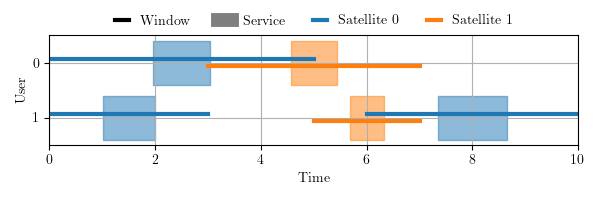

In [2]:
reset_id_counters()
requests = [
    Request(user_id=0, start=0.0, end=10.0, duration=2.0, arrival=0.0),
    Request(user_id=1, start=3.0, end=10.0, duration=3.0, arrival=0.0),
    Request(user_id=1, start=0.0, end=10.0, duration=2.0, arrival=3.0),
]
request_dict = {r.id: r for r in requests}

service_windows = [
    # Satellite 0
    ServiceWindow(user_id=0, satellite_id=0, start=0.0, end=5.0),
    ServiceWindow(user_id=1, satellite_id=0, start=0.0, end=3.0),
    ServiceWindow(user_id=1, satellite_id=0, start=6.0, end=10.0),
    # Satellite 1
    ServiceWindow(user_id=0, satellite_id=1, start=3.0, end=7.0),
    ServiceWindow(user_id=1, satellite_id=1, start=5.0, end=7.0),
]

N_sat = 2
N_usr = 2
N_req = len(requests)
N_win = len(service_windows)

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times = np.ones((N_sat, N_req, N_req))
for i in range(N_sat):
    transition_times[i, np.diag_indices(N_req)] = 0
transition_times[0, :] = 0
transition_times[:, 0] = 0


t_step = 1
t_final = 10
N_steps = int(t_final / t_step)
CN0 = np.ones((2, N_usr, N_steps))

data_gen = -0.2 * np.ones((N_sat, N_steps))
energy_gen = 0.2 * np.ones((N_sat, N_steps))

problem = PntSchedulingProblem(
    t_step=t_step,
    t_final=t_final,
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    CN0=CN0,
    max_energy=2 / 0.2,
    min_energy=2,
    max_data=8,
    min_data=8 / 0.8 * 0.2,
    payload_data_gen=1,
    payload_energy_gen=-1,
    energy_gen=energy_gen,
    data_gen=data_gen,
)

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
plotting.plot_requests_service_windows(requests, service_windows, ax=ax)
plt.tight_layout()

# No constraints

In [5]:
# Forward search
d = 8
gamma = 0.7
N_max = 5
d_min = 1
problem.set_current_time(0)
problem.set_current_policy(None)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 2.76
Percentage of requests served:
[100.0, 100.0, nan]
Total: 2.76


In [6]:
policy

[(State(t=[0. 0.], d=[5. 5.], e=[6. 6.], req=[0.0, 0.0, 0.0]),
  Action(sat=0, usr=1, req=1, start=0.00, dur=3.00)),
 (State(t=[3. 0.], d=[7.4 5. ], e=[3.6 6. ], req=[0.0, 3.0, 0.0]),
  Action(sat=1, usr=0, req=0, start=3.00, dur=2.00)),
 (State(t=[3. 5.], d=[7.4 6. ], e=[3.6 5. ], req=[2.0, 3.0, 0.0]), None)]

Total reward: 2.76


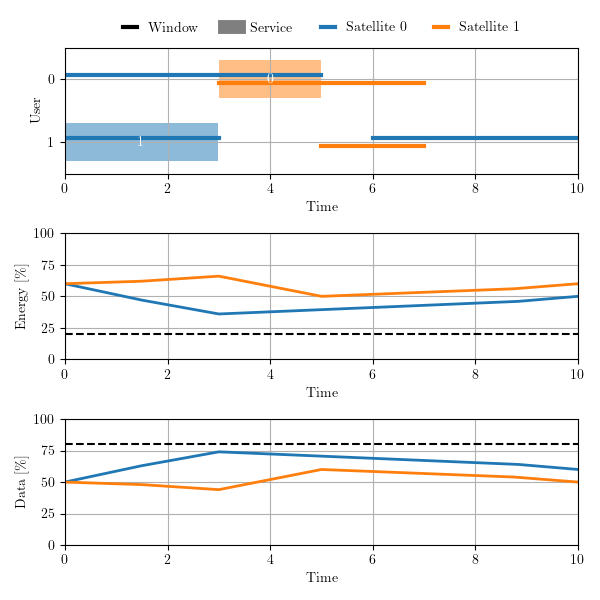

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [12]:
old_policy = policy
arrival_times = sorted(list(set([r.arrival for r in requests])))
arrival_times


[0.0, 3.0]

In [13]:
# Forward search
d = 6
gamma = 0.7
N_max = 5
T_min = 10
problem.set_current_time(3)
problem.set_current_policy(old_policy)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 0.14
Percentage of requests served:
[100.0, 100.0, 100.0]
Total: 0.14


Total reward: 0.14


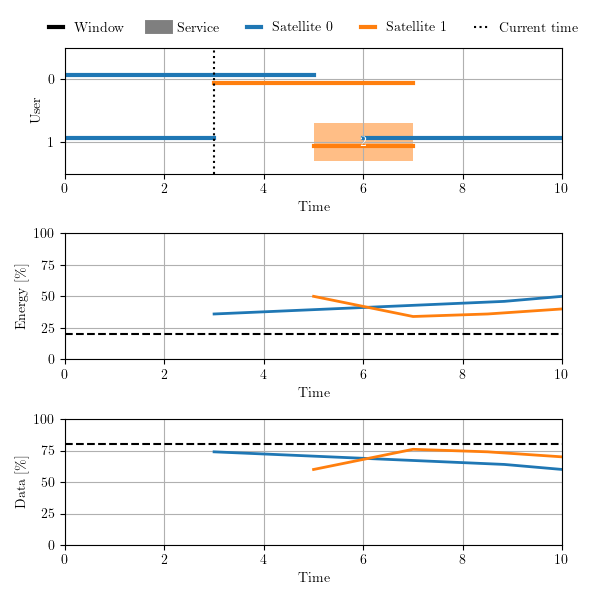

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=3
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [15]:
merged_policy = problem.merge_policies(policy)

Total reward: 2.90


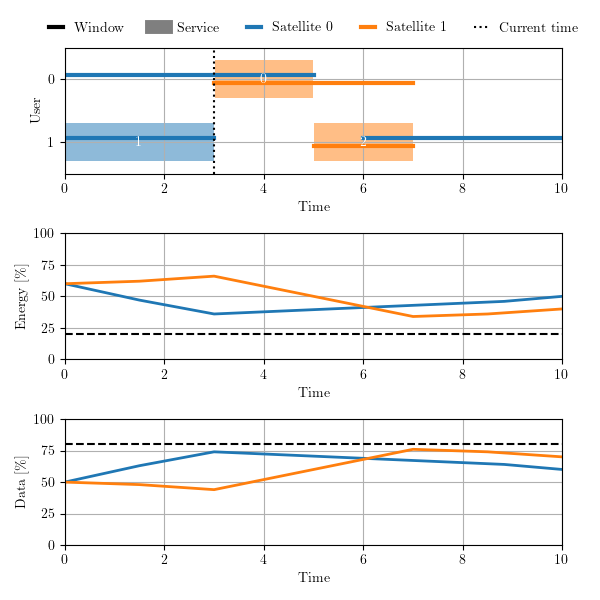

In [16]:
policy = merged_policy
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=problem.current_time
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

# Constraints

In [97]:
# Forward search

# Parameters
d = 5
gamma = 0.7
N_max = 5
d_min = 2

# Config
problem.set_current_time(0)
problem.set_current_policy(None)

# Solve
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)

# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 0.00
Percentage of requests served:
[0.0, 0.0, nan]
Total: 0.0


In [98]:
actions = [
    Action(satellite_id=0, request=requests[0], start=3.0, duration=2.0),
    Action(satellite_id=0, request=requests[1], start=6.0, duration=1.0),
]

s = problem.initial_state()
policy = list[tuple[State, Action]]()
for a in actions:
    policy.append((s, a))
    s = problem.transition_function(s, a)
policy.append((s, None))

Total reward: 0.42


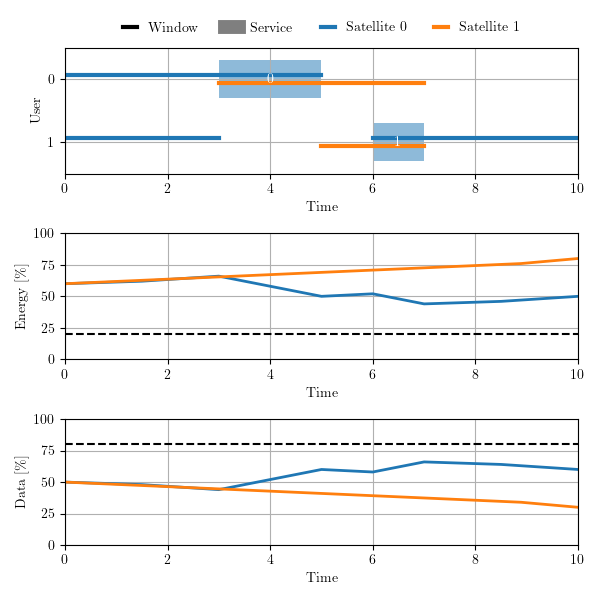

In [99]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [100]:
# Config
old_policy = policy
problem.set_current_time(3)
problem.set_current_policy(old_policy, constrained=True)
problem.initial_state()

State(t=[5. 3.], d=[6. 5.], e=[5. 6.], req=[2.0, 1.0, 0.0])

Total reward: 0.42


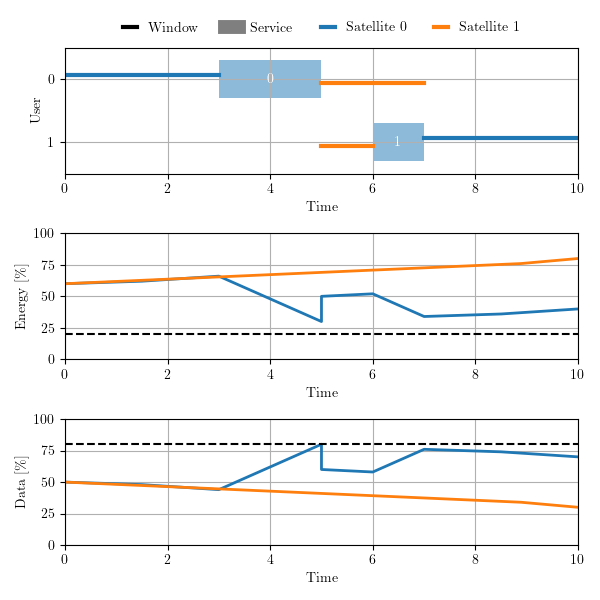

In [101]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(requests, problem.constrained_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [117]:
# Forward search
d = 6
gamma = 0.7
N_max = 10
d_min = 10
problem.set_current_time(3)
problem.set_current_policy(old_policy, constrained=True)
s = problem.initial_state()

In [118]:
problem.available_actions(s, N_max, d_min)

[Action(sat=1, usr=None, req=None, start=3.00, dur=7.00),
 Action(sat=1, usr=1, req=1, start=5.00, dur=1.00),
 Action(sat=1, usr=1, req=2, start=5.00, dur=1.00)]

In [119]:
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, N_max=N_max, d_min=d_min)
# Metrics
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy)
pp.pprint(percentage)
print("Total:", round(problem.total_reward(policy, gamma=gamma), 2))

Total reward: 0.16
Percentage of requests served:
[100.0, 100.0, 0.0]
Total: 0.16


Total reward: 0.16


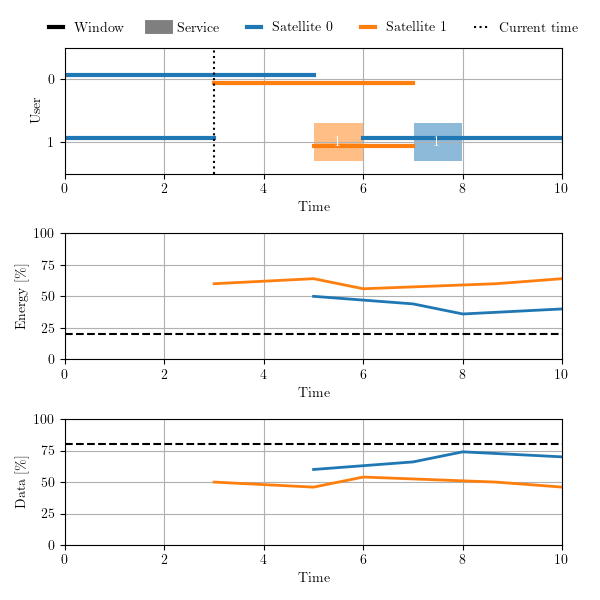

In [120]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, policy, ax=axs[0], current_time=3
)
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

In [121]:
merged_policy = problem.merge_policies(policy)

Total reward: 0.63


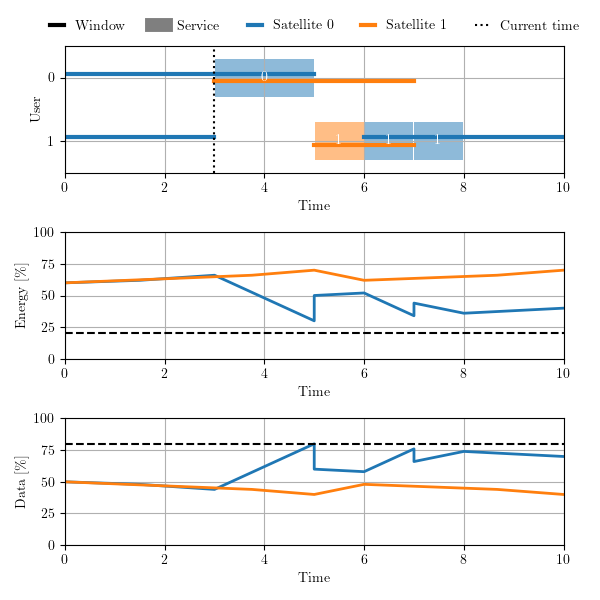

In [123]:
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
print(f"Total reward: {problem.total_reward(merged_policy, gamma=gamma):.2f}")
plotting.plot_requests_service_windows(
    requests, service_windows, merged_policy, ax=axs[0], current_time=problem.current_time
)
plotting.plot_resources(problem, merged_policy, ax=axs[1:])
plt.tight_layout()
plt.show()

In [249]:
# MCTS
d = 5
gamma = 0.9
n = int(1e3)
c = 10
N_max = 5
d_min = 1
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=d, gamma=gamma, n=n, c=c, N_max=N_max, d_min=d_min)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()

AttributeError: 'State' object has no attribute 'time'

                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Apr 04 02:23:38 PM: Your problem has 80 variables, 291 constraints, and 0 parameters.
(CVXPY) Apr 04 02:23:38 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 04 02:23:38 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 04 02:23:38 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 04 02:23:38 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Compiling problem (target solver=GUROBI).


(CVXPY) Apr 04 02:23:38 PM: Applying reduction QpMatrixStuffing
(CVXPY) Apr 04 02:23:38 PM: Applying reduction GUROBI
(CVXPY) Apr 04 02:23:38 PM: Finished problem compilation (took 6.473e-02 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Apr 04 02:23:38 PM: Invoking solver GUROBI  to obtain a solution.
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-11
Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D60)

CPU model: Apple M3 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 574 rows, 152 columns and 1848 nonzeros
Model fingerprint: 0x1f80aef1
Variable types: 72 continuous, 80 integer (80 binary)
Coefficient statistics:
  

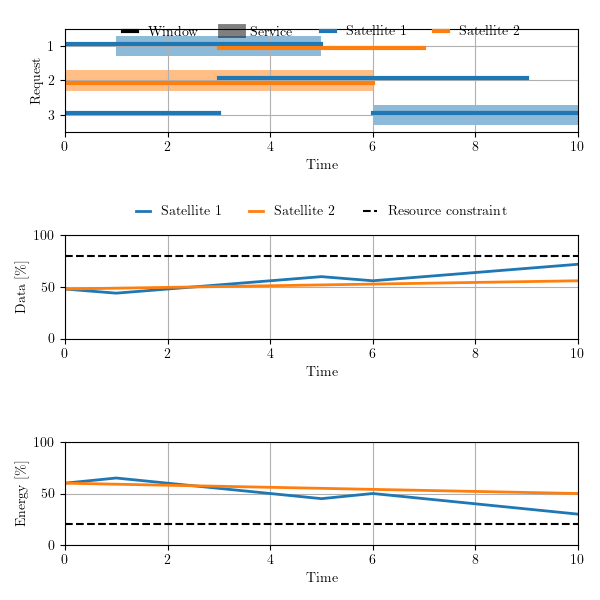

In [ ]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step_factor=1)
print(f"Total reward: {problem.total_reward(policy, gamma=gamma):.2f}")
fig, axs = plt.subplots(3, 1, figsize=(6, 6))
plotting.plot_requests_service_windows(requests, service_windows, policy, ax=axs[0])
plotting.plot_resources(problem, policy, ax=axs[1:])
plt.show()